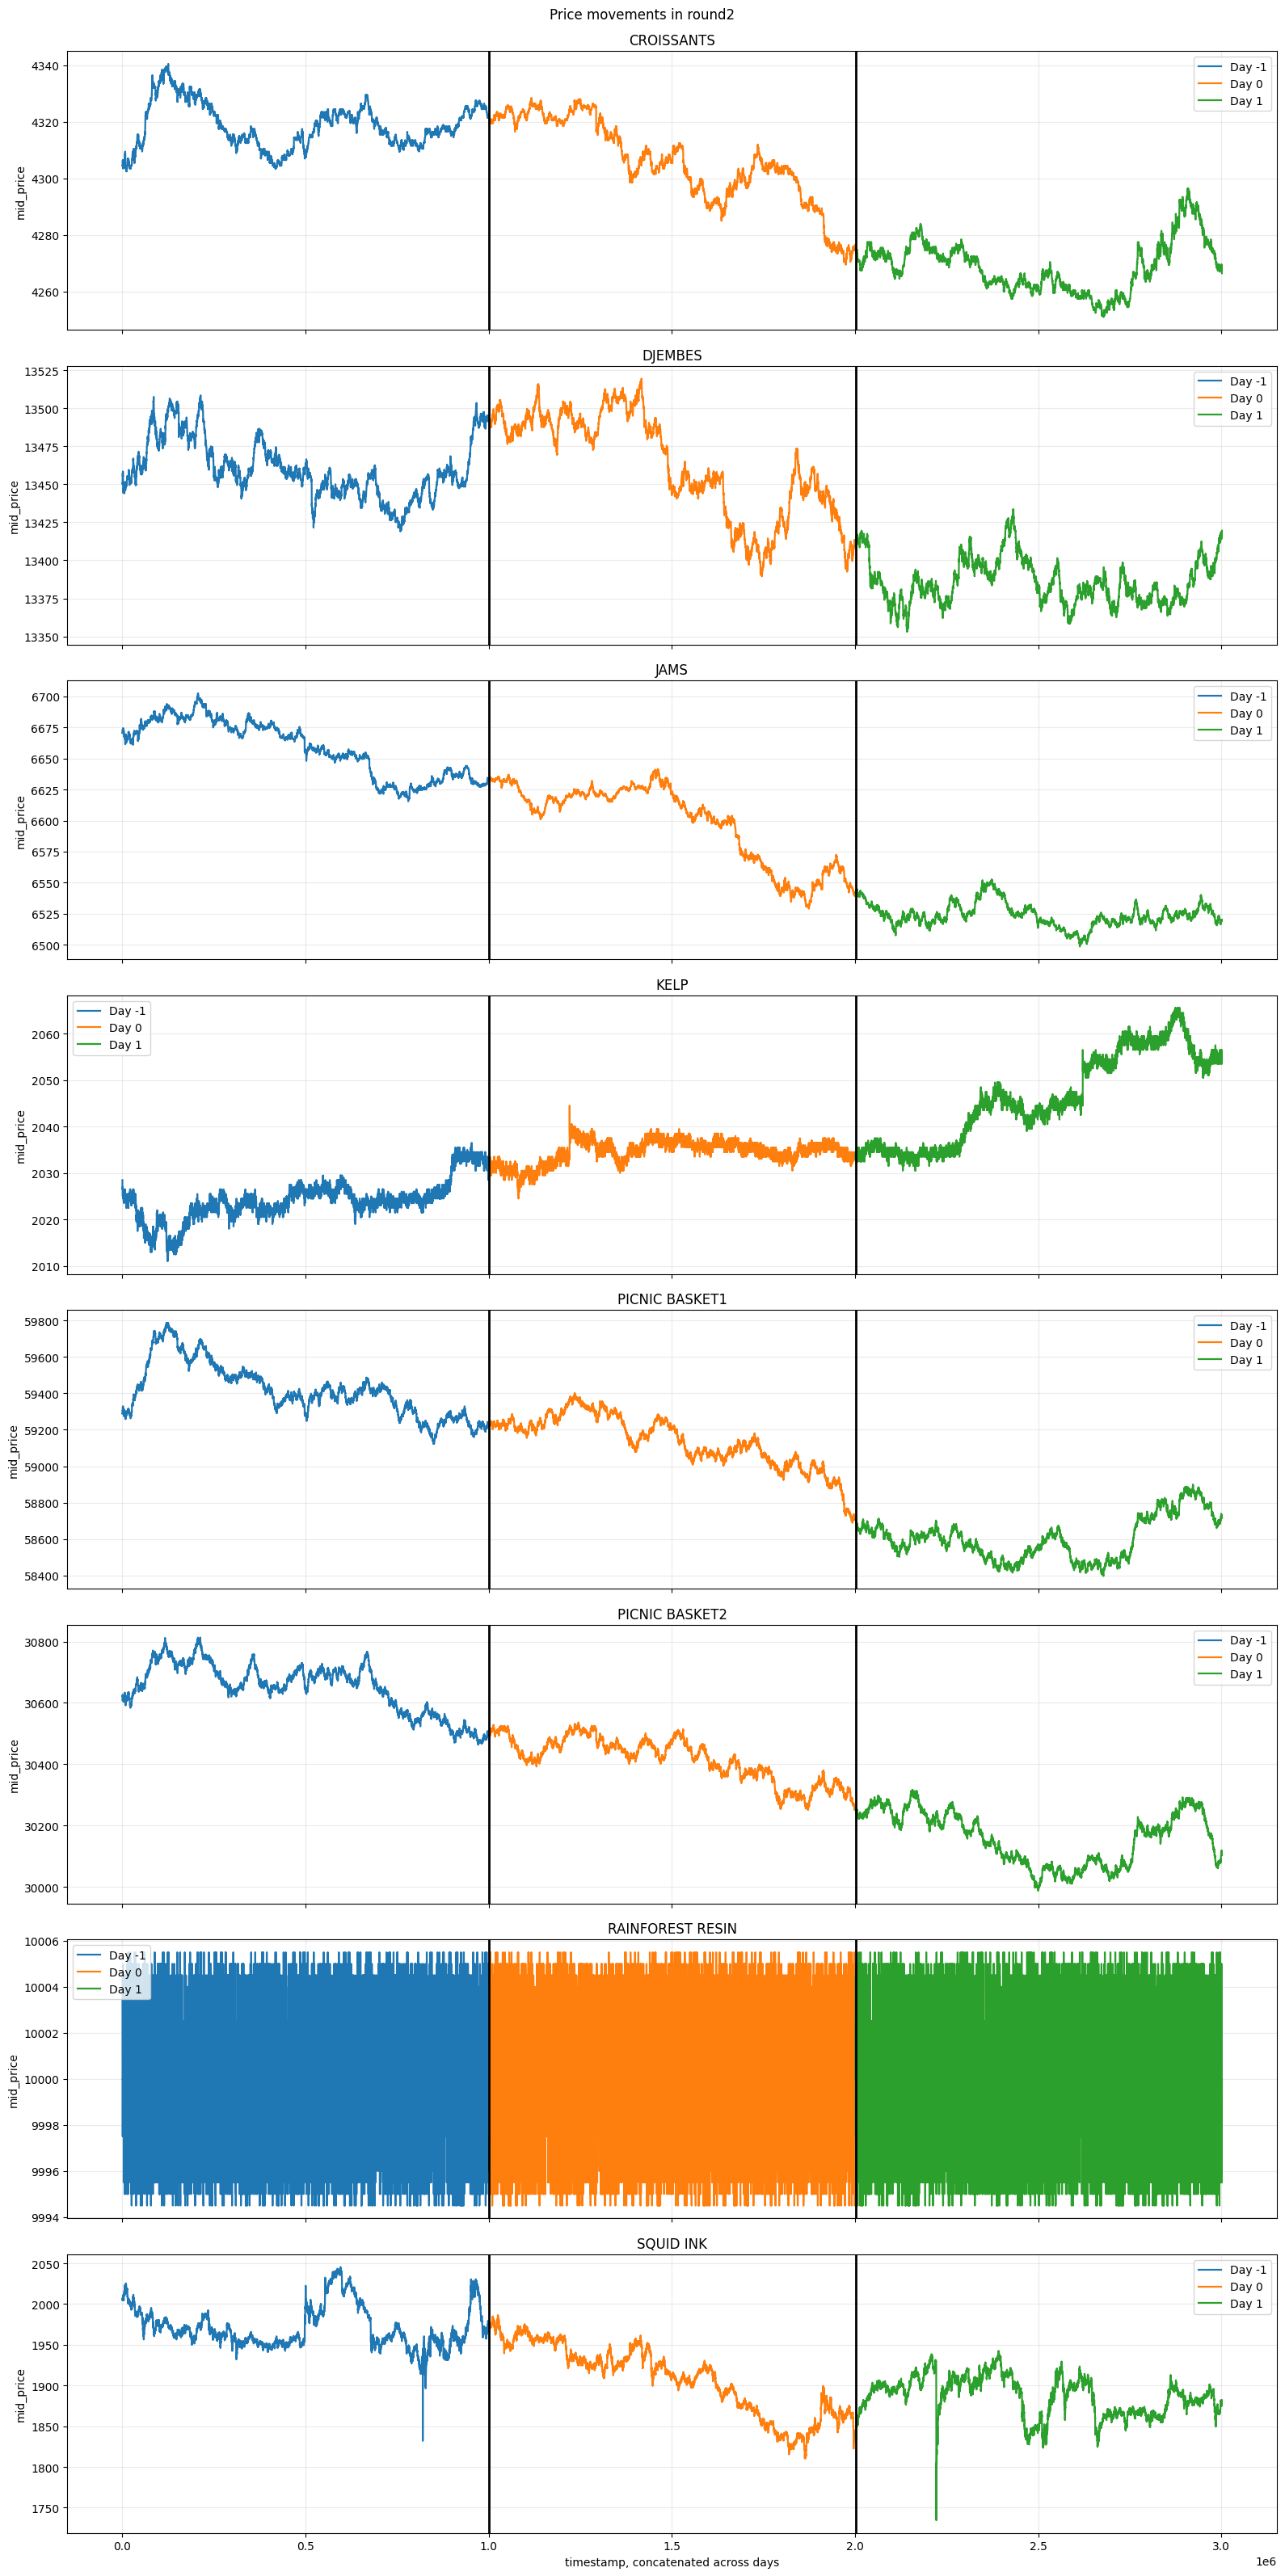

In [9]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

ROUND_NUMBER = 2
candidate_folders = [
    Path(f"round{ROUND_NUMBER}"),
    Path("2025") / f"round{ROUND_NUMBER}",
]
ROUND_FOLDER = next((folder for folder in candidate_folders if folder.exists()), None)
if ROUND_FOLDER is None:
    raise FileNotFoundError(f"Could not find the round{ROUND_NUMBER} folder. Tried: round{ROUND_NUMBER}, 2025/round{ROUND_NUMBER}")

PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
products = sorted(prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = prices[prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = prices[prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()


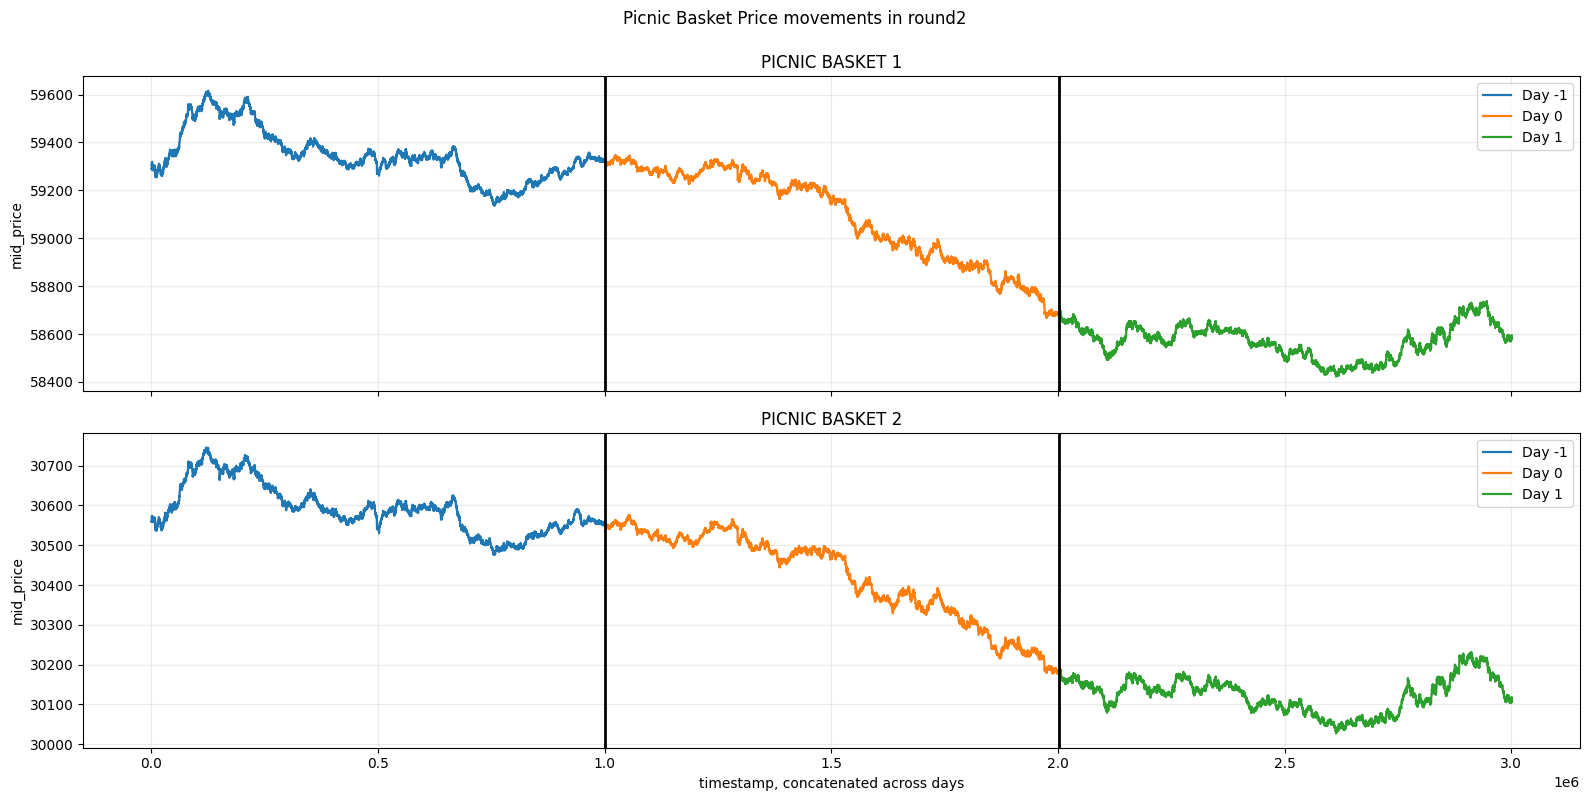

In [10]:
# Define picnic baskets (ETFs)
baskets = {
    "PICNIC_BASKET_1": {"CROISSANTS": 6, "JAMS": 3, "DJEMBES": 1},
    "PICNIC_BASKET_2": {"CROISSANTS": 4, "JAMS": 2},
}

# Compute basket prices efficiently
basket_prices_list = []
for basket_name, composition in baskets.items():
    # Get all data for components in this basket
    component_names = list(composition.keys())
    basket_data = prices[prices["product"].isin(component_names)].copy()
    
    if basket_data.empty:
        continue
    
    # Pivot to have products as columns
    pivoted = basket_data.pivot_table(
        index=["day", "timestamp"], 
        columns="product", 
        values="mid_price",
        aggfunc="first"
    )
    
    # Filter to rows where all components are present
    component_cols = [col for col in component_names if col in pivoted.columns]
    valid_rows = pivoted[component_cols].dropna()
    
    if valid_rows.empty:
        continue
    
    # Compute basket price
    basket_price = sum(valid_rows[comp] * qty for comp, qty in composition.items())
    
    # Create result dataframe
    result = valid_rows[[component_cols[0]]].copy()
    result.columns = ["_temp"]
    result["mid_price"] = basket_price
    result["product"] = basket_name
    result = result.reset_index()[["day", "timestamp", "product", "mid_price"]]
    basket_prices_list.append(result)

basket_df = pd.concat(basket_prices_list, ignore_index=True) if basket_prices_list else pd.DataFrame()
basket_products = sorted(basket_df["product"].unique()) if not basket_df.empty else []

if len(basket_products) > 0:
    # Create visualization
    fig, axes = plt.subplots(len(basket_products), 1, figsize=(16, max(4, 4 * len(basket_products))), sharex=True)
    if len(basket_products) == 1:
        axes = [axes]

    for ax, product in zip(axes, basket_products):
        product_prices = basket_df[basket_df["product"] == product].sort_values(["day", "timestamp"])

        for day in DAY_LABELS:
            day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
            if day_prices.empty:
                continue

            x_values = day_prices["timestamp"] + x_offsets[day]
            ax.plot(
                x_values,
                day_prices["mid_price"],
                color=color_map[day],
                linewidth=1.6,
                label=f"Day {day}",
            )

        for separator in separator_positions[:-1]:
            ax.axvline(separator, color="black", linewidth=2)

        ax.set_title(product.replace("_", " "))
        ax.set_ylabel("mid_price")
        ax.grid(alpha=0.25)
        ax.legend(loc="best")
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)

    axes[-1].set_xlabel("timestamp, concatenated across days")
    fig.suptitle(f"Picnic Basket Price movements in {ROUND_FOLDER.name}", y=0.995)
    fig.tight_layout()
    plt.show()
else:
    print("No basket data found - check that component products exist in the price data")


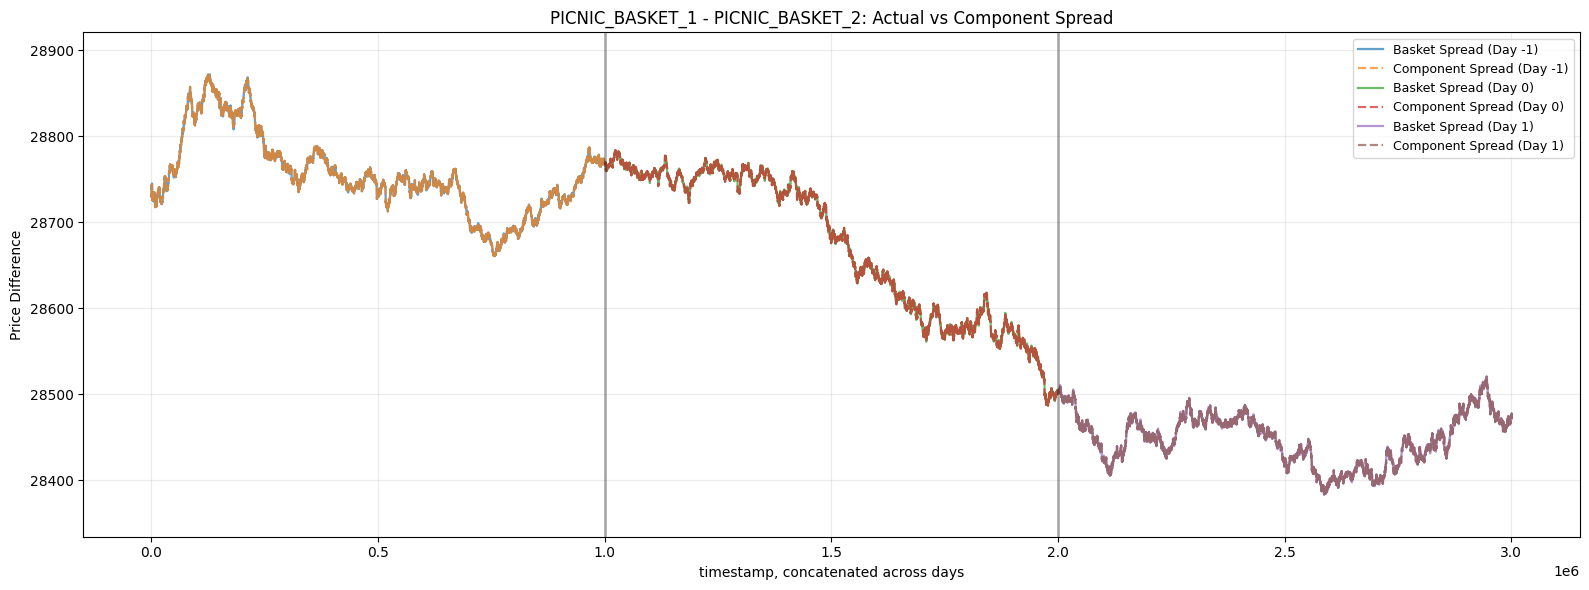

In [11]:
# Compute basket spread and component spread
# Get basket prices for comparison
basket1 = basket_df[basket_df["product"] == "PICNIC_BASKET_1"].sort_values(["day", "timestamp"]).reset_index(drop=True)
basket2 = basket_df[basket_df["product"] == "PICNIC_BASKET_2"].sort_values(["day", "timestamp"]).reset_index(drop=True)

# Merge baskets on day and timestamp
spread_data = basket1[["day", "timestamp", "mid_price"]].rename(columns={"mid_price": "basket1_price"}).merge(
    basket2[["day", "timestamp", "mid_price"]].rename(columns={"mid_price": "basket2_price"}),
    on=["day", "timestamp"],
    how="inner"
)

# Basket spread: BASKET1 - BASKET2
spread_data["basket_spread"] = spread_data["basket1_price"] - spread_data["basket2_price"]

# Component spread: (6-4)*CROISSANTS + (3-2)*JAMS + (1-0)*DJEMBES = 2*CROISSANTS + 1*JAMS + 1*DJEMBES
component_prices = prices[prices["product"].isin(["CROISSANTS", "JAMS", "DJEMBES"])].copy()
component_pivot = component_prices.pivot_table(
    index=["day", "timestamp"],
    columns="product",
    values="mid_price",
    aggfunc="first"
).reset_index()

# Merge with spread data
spread_data = spread_data.merge(
    component_pivot,
    on=["day", "timestamp"],
    how="inner"
)

# Compute theoretical component spread
spread_data["component_spread"] = (
    2 * spread_data.get("CROISSANTS", 0)
    + 1 * spread_data.get("JAMS", 0)
    + 1 * spread_data.get("DJEMBES", 0)
)

# Plot
fig, ax = plt.subplots(figsize=(16, 6))

for day in sorted(spread_data["day"].unique()):
    day_data = spread_data[spread_data["day"] == day].sort_values("timestamp")
    x_values = day_data["timestamp"] + x_offsets[day]

    ax.plot(x_values, day_data["basket_spread"], linewidth=1.6, label=f"Basket Spread (Day {day})", alpha=0.7)
    ax.plot(x_values, day_data["component_spread"], linewidth=1.6, linestyle="--", label=f"Component Spread (Day {day})", alpha=0.7)

for separator in separator_positions[:-1]:
    ax.axvline(separator, color="black", linewidth=2, alpha=0.3)

# Force zoomed y-axis to data range (instead of including 0 by default)
y_values = pd.concat([spread_data["basket_spread"], spread_data["component_spread"]], ignore_index=True).dropna()
y_min = y_values.min()
y_max = y_values.max()
y_range = y_max - y_min
pad = max(1e-9, y_range * 0.10)
ax.set_ylim(y_min - pad, y_max + pad)

# Only draw the zero line when it is inside the visible zoomed range
if y_min - pad <= 0 <= y_max + pad:
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":", alpha=0.5)

ax.set_title("PICNIC_BASKET_1 - PICNIC_BASKET_2: Actual vs Component Spread")
ax.set_ylabel("Price Difference")
ax.set_xlabel("timestamp, concatenated across days")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
plt.show()


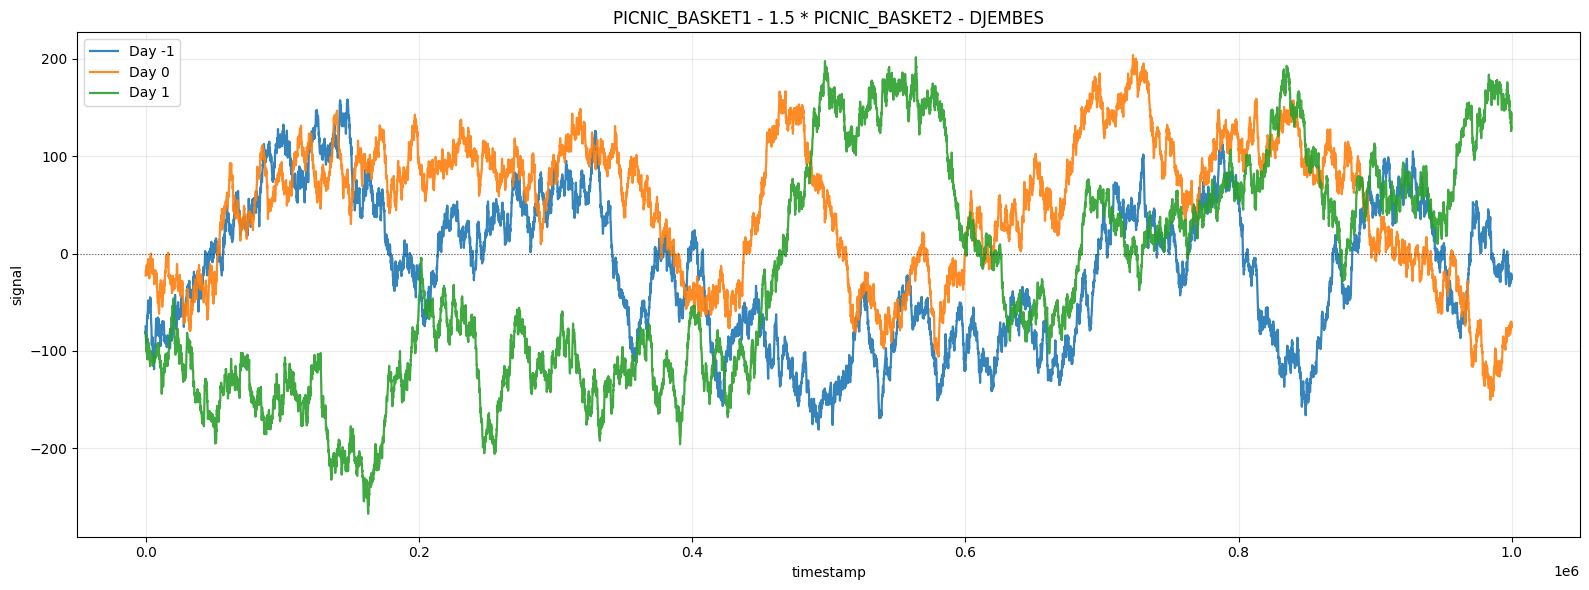

In [15]:
# Simple version: load df, construct signal column, plot

# 1) Load the round-2 price files into one dataframe
frames = []
for file_path in PRICE_FILES:
    m = DAY_RE.search(file_path.name)
    if m is None:
        continue
    day = int(m.group(1))
    df_day = pd.read_csv(file_path, sep=";")
    df_day["day"] = day
    df_day["timestamp"] = pd.to_numeric(df_day["timestamp"], errors="coerce")
    df_day["mid_price"] = pd.to_numeric(df_day["mid_price"], errors="coerce")
    frames.append(df_day[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError("No valid round-2 price files found.")

raw = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])

# 2) Build signal column: BASKET_1 - 1.5 * BASKET_2 - DJEMBES
pivot = raw.pivot_table(
    index=["day", "timestamp"],
    columns="product",
    values="mid_price",
    aggfunc="first",
).reset_index()

required = ["PICNIC_BASKET1", "PICNIC_BASKET2", "DJEMBES"]
missing = [c for c in required if c not in pivot.columns]
if missing:
    raise ValueError(f"Missing required products in data: {missing}")

pivot = pivot.dropna(subset=required).copy()
pivot["signal"] = pivot["PICNIC_BASKET1"] - 1.5 * pivot["PICNIC_BASKET2"] - pivot["DJEMBES"]

# 3) Plot
fig, ax = plt.subplots(figsize=(16, 6))
for day in sorted(pivot["day"].unique()):
    d = pivot[pivot["day"] == day].sort_values("timestamp")
    ax.plot(d["timestamp"], d["signal"], linewidth=1.6, label=f"Day {int(day)}", alpha=0.9)

ax.axhline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.6)
ax.set_title("PICNIC_BASKET1 - 1.5 * PICNIC_BASKET2 - DJEMBES")
ax.set_xlabel("timestamp")
ax.set_ylabel("signal")
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
plt.show()
